# P2 · 03 — What did it learn? Importance & (careful) tuning

Two practical skills: **interpreting** a tree model's feature importances, and
**tuning** without overfitting when you only have ~80 rows.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from lightgbm import LGBMRegressor
from src import features as F, ml, backtest as bt
q = data.load_quarterly(); logy = np.log(q["gdp_nsa"])
X, ytar = F.build_supervised(logy, target="growth")
model = LGBMRegressor(**ml.DEFAULT_PARAMS).fit(X, ytar)

### Feature importance — which signals drive the growth forecast?

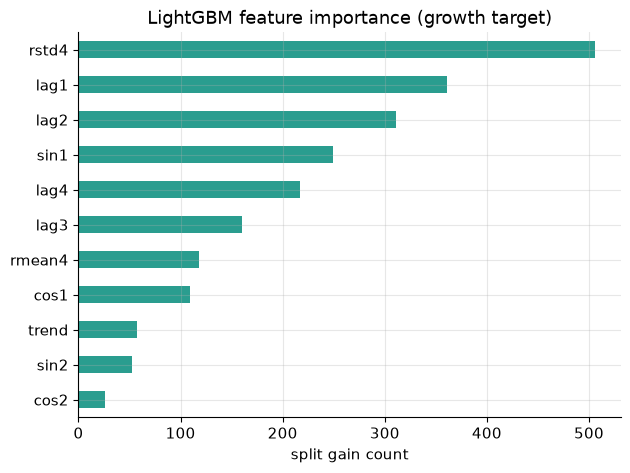

rstd4     506
lag1      361
lag2      311
sin1      249
lag4      217
lag3      160
rmean4    118
cos1      109
trend      57
sin2       52
cos2       26
dtype: int32

In [2]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax, color="#2a9d8f")
ax.set(title="LightGBM feature importance (growth target)", xlabel="split gain count")
plt.show()
imp.sort_values(ascending=False)

Read it with care: tree "importance" counts how often a feature is split on, not a
causal effect. Expect the **recent lags** and the **seasonal Fourier / lag4** terms
to dominate — growth this quarter is driven by recent momentum and the same quarter
last year. (Note `trend` should be near-useless on the growth target — exactly the
§01 lesson, now visible in the importances.)

### Tuning on tiny data: regularisation, judged by backtest

With ~80 rows the enemy is overfitting. We sweep one knob — `num_leaves` (tree
complexity) — and let the **rolling-origin MASE** pick, never the training fit.

In [3]:
rows = {}
for nl in [3, 5, 7, 15, 31]:
    f = ml.gbm_recursive_forecaster(target="growth", params={"num_leaves": nl})
    res = bt.rolling_origin(q["gdp_nsa"], f, initial=40, h=4)
    from src import metrics as M
    rows[nl] = M.mase(res.y_true, res.y_pred, q["gdp_nsa"].to_numpy(), 4)
sweep = pd.Series(rows, name="MASE"); sweep.index.name = "num_leaves"
print(sweep.round(3))
print("best num_leaves:", sweep.idxmin())

num_leaves
3     0.744
5     0.823
7     0.819
15    0.818
31    0.818
Name: MASE, dtype: float64
best num_leaves: 3


Smaller trees (fewer leaves) usually win here — **more capacity is worse** when data
is scarce, because the model memorises noise. This is the bias–variance trade-off in
the open: on big data you'd let trees grow; on 80 points you clamp them down.

**Leakage checklist (burn it in):**
1. Features use only the past (`hist[:t]`). ✅ enforced in `feature_row`.
2. No scaler/encoder fit on the full series before splitting.
3. CV respects time order — **rolling origin**, never shuffled K-fold.
4. The target's own value never appears among its features.

---
**Next (04):** the capstone — ML vs the best classical models, head to head, and an
honest verdict on when each wins.